# Ensembled anomaly detection
In this example we are using google trends search interest data with "Redfin" as the search term. Search interest over a specific Week period, displayed on a relative scale from 0 to 100, where 100 signifies the peak interest for the Week period of the chart. A value of 50 indicates half the popularity of the peak, and 0 suggests insufficient data.

We use an ensembled approach here where we use 3 different models to make predictions and get confidence intervals

In [1]:
import pandas as pd
import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt
from pmdarima.model_selection import train_test_split
import statsmodels.tsa.statespace.exponential_smoothing as sm_state
from prophet import Prophet

In [2]:
confidence_interval_size = 0.01
google_trends_df = pd.read_csv('google_trends_redfin.csv')
google_trends_df['Week'] = pd.to_datetime(google_trends_df['Week'])
display(google_trends_df.head())

,Week,Redfin
0,2023-02-12,69
1,2023-02-19,70
2,2023-02-26,70
3,2023-03-05,70
4,2023-03-12,67


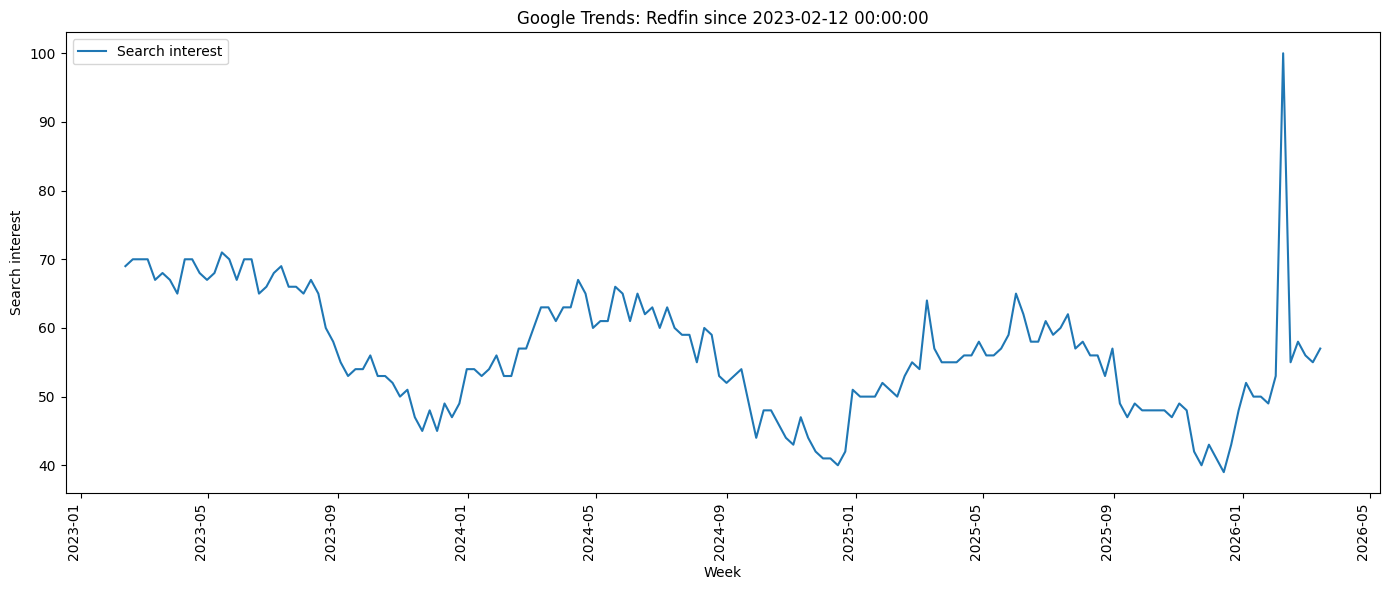

In [3]:
# plot data
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(google_trends_df['Week'], google_trends_df['Redfin'], label = "Search interest")
plt.legend()
plt.title(f'Google Trends: Redfin since {google_trends_df['Week'].min()}')
plt.xlabel("Week")
plt.ylabel('Search interest')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [4]:
# ARIMA
cutoff_date = '2026-01-31'
train_size = len(google_trends_df[google_trends_df['Week']<cutoff_date])
test_size = len(google_trends_df[google_trends_df['Week']>=cutoff_date])
search_interest = google_trends_df[-(train_size+test_size):]['Redfin'].to_numpy()
train, test = train_test_split(search_interest, train_size=train_size)

arima_model = pm.auto_arima(train, start_p = 0, start_q = 0, d = 0, max_p = 5, max_q = 5, out_of_sample_size=10, suppress_warnings=True, stepwise=True, error_action='ignore')

In [5]:
# exponential smoothing
model = sm_state.ExponentialSmoothing(train, trend=True, seasonal=52)
fit = model.fit()

c:\Users\Tina\TimeSeriesAnomalyDetection\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [6]:
# prophet
training_df = google_trends_df[google_trends_df['Week']>=cutoff_date].copy()
prophet_friendly_df = training_df.rename(columns = {'Week':'ds', 'Redfin':"y"})

prophet_model = Prophet(interval_width=1-confidence_interval_size)
prophet_model.fit(prophet_friendly_df)

15:21:49 - cmdstanpy - INFO - Chain [1] start processing
15:21:49 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# Ensemble with voting

# get arima predictions
arima_pred, conf_int = arima_model.predict(n_periods=test.shape[0], return_conf_int = True, alpha = confidence_interval_size)
# get exponential smoothing predictions
test_dates_list = list(google_trends_df[google_trends_df['Week']>=cutoff_date]['Week'])
exp_smoothing_pred = fit.get_prediction(start=train.shape[0], end=train.shape[0]+test.shape[0]-1)
exp_smoothing_pred_summary = exp_smoothing_pred.summary_frame(alpha=confidence_interval_size)[['mean', 'mean_ci_lower', 'mean_ci_upper']]
# get prophet predictions
future = pd.DataFrame(google_trends_df[google_trends_df['Week']>=cutoff_date]['Week']).rename(columns = {'Week':'ds'}).copy()
prophet_pred = prophet_model.predict(future)
# final data frame with votes
preds_df = google_trends_df[google_trends_df['Week']>=cutoff_date].copy()
preds_df['arima_predictions'] = arima_pred
preds_df['arima_lower_conf_int'] = conf_int[:, 0]
preds_df['arima_upper_conf_int'] = conf_int[:, 1]
preds_df['prophet_predictions'] = list(prophet_pred['yhat'])
preds_df['prophet_lower_conf_int'] = list(prophet_pred['yhat_lower'])
preds_df['prophet_upper_conf_int'] = list(prophet_pred['yhat_upper'])
preds_df['exp_smoothing_predictions'] = list(exp_smoothing_pred_summary['mean'])
preds_df['exp_smoothing_lower_conf_int'] = list(exp_smoothing_pred_summary['mean_ci_lower'])
preds_df['exp_smoothing_upper_conf_int'] = list(exp_smoothing_pred_summary['mean_ci_upper'])
preds_df['arima_anomaly'] = np.where((preds_df['Redfin'] < preds_df['arima_lower_conf_int'])|(preds_df['Redfin'] > preds_df['arima_upper_conf_int']), 1, 0)
preds_df['prophet_anomaly'] = np.where((preds_df['Redfin'] < preds_df['prophet_lower_conf_int'])|(preds_df['Redfin'] > preds_df['prophet_upper_conf_int']), 1, 0)
preds_df['exp_smoothing_anomaly'] = np.where((preds_df['Redfin'] < preds_df['exp_smoothing_lower_conf_int'])|(preds_df['Redfin'] > preds_df['exp_smoothing_upper_conf_int']), 1, 0)
preds_df['anomaly'] = np.where(preds_df['arima_anomaly']+preds_df['prophet_anomaly']+preds_df['exp_smoothing_anomaly']>=2, 1, 0)

In [8]:
preds_df

,Week,Redfin,arima_predictions,arima_lower_conf_int,arima_upper_conf_int,prophet_predictions,prophet_lower_conf_int,prophet_upper_conf_int,exp_smoothing_predictions,exp_smoothing_lower_conf_int,exp_smoothing_upper_conf_int,arima_anomaly,prophet_anomaly,exp_smoothing_anomaly,anomaly
155,2026-02-01,53,49.471635,42.223329,56.719940,70.223934,32.144972,106.432788,49.110721,44.110928,54.110514,0,0,0,0
156,2026-02-08,100,49.703687,40.444675,58.962700,67.471584,29.390159,104.185909,50.140240,44.946873,55.333606,1,0,1,1
157,2026-02-15,55,49.928445,39.117954,60.738936,64.719233,27.121195,98.755460,52.791193,47.411077,58.171308,0,0,0,0
158,2026-02-22,58,50.146137,38.059895,62.232379,61.966883,25.598035,97.441095,53.464384,47.903656,59.025112,0,0,0,0
159,2026-03-01,56,50.356986,37.185800,63.528173,59.214533,22.637310,96.512521,54.136520,48.400737,59.872303,0,0,0,0
160,2026-03-08,55,50.561207,36.447834,64.674580,56.462182,19.118213,93.098106,57.414438,51.508663,63.320214,0,0,0,0
161,2026-03-15,57,50.759008,35.815662,65.702354,53.709832,19.718640,94.210184,55.364891,49.293761,61.436021,0,0,0,0


In [9]:
print('dates where anomalies detected:',preds_df[preds_df['anomaly']==1]['Week'].values)

dates where anomalies detected: ['2026-02-08T00:00:00.000000']


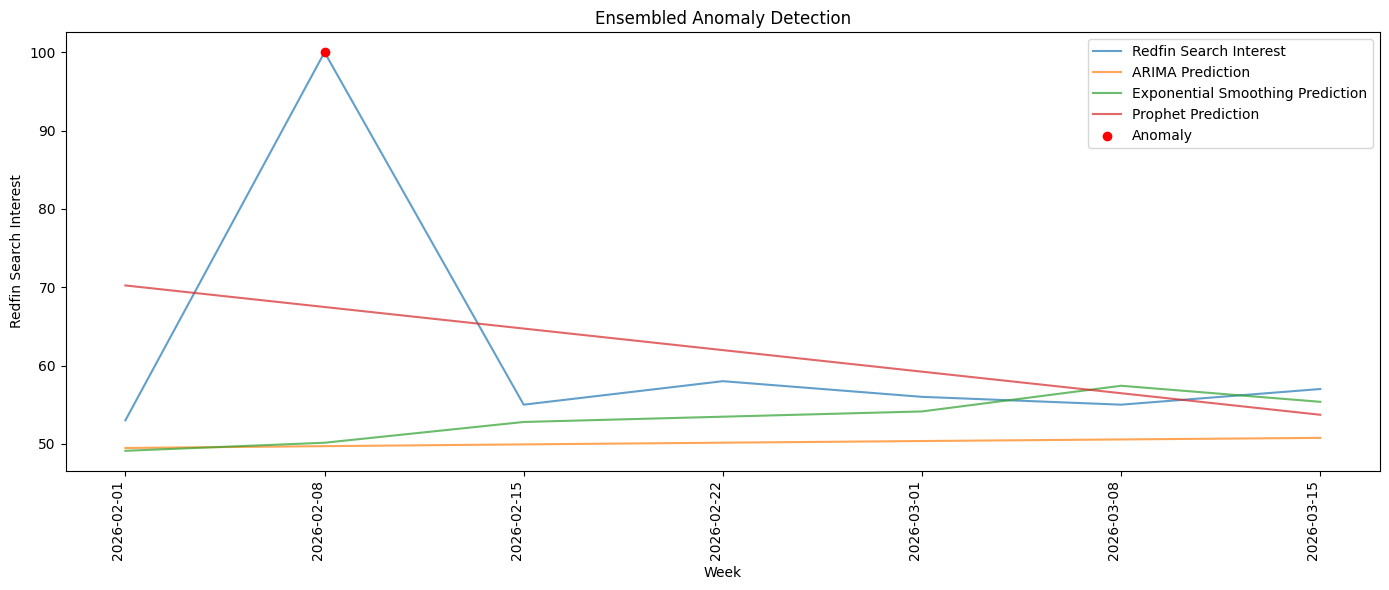

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(preds_df['Week'], preds_df['Redfin'], label = 'Redfin Search Interest', alpha = 0.7)
plt.plot(preds_df['Week'], preds_df['arima_predictions'], label = 'ARIMA Prediction', alpha = 0.7)
plt.plot(preds_df['Week'], preds_df['exp_smoothing_predictions'], label = 'Exponential Smoothing Prediction', alpha = 0.7)
plt.plot(preds_df['Week'], preds_df['prophet_predictions'], label = 'Prophet Prediction', alpha = 0.7)
plt.scatter(
    preds_df.loc[preds_df[preds_df['anomaly']==1].index, 'Week'],
    preds_df.loc[preds_df[preds_df['anomaly']==1].index, 'Redfin'],
    color = 'red', label = 'Anomaly', zorder = 5
)
plt.legend()
plt.title('Ensembled Anomaly Detection')
plt.xlabel("Week")
plt.ylabel('Redfin Search Interest')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()